# Ciência de Dados Geoespaciais - Modelagem

**Maj Diego - 2° Semestre / 2026**

**Objetivos**

1. Explicar o conceito de **classificadores lineares**;
2. Explicar e aplicar modelos de **regressão logística**;
3. Explicar e aplicar modelos de **árvores de decisão**;
4. Explicar e aplicar modelos de **floresta aleatória**;
5. Explicar e aplicar modelos de **suport vector machine (SVM)**;
6. Explicar e aplicar modelos de **regressão linear**;
7. Explicar e aplicar modelos de **árvores de regressão**;
8. Explicar e aplicar modelos de **floresta de regressão**;
9. Explicar o conceito de **redes neurais**;
10. Explicar e aplicar modelos de **multilayer perceptron (MLP) + Softmax Loss**;
11. Explicar e aplicar modelos de **MLP + Cross-Entropy-Loss**;
12. Explicar o conceito de **deep learning**


## O Contexto

Na etapa de **Modelagem** — vamos *aprender uma função* a partir dos dados para **predizer** e **prever** valores em casos novos ou **explicar relações**

Prospecção $\rightarrow$ Pré-Processamento $\rightarrow$ Exploração $\rightarrow$ **Modelagem** $\rightarrow$ Comunicação

- Aprendizado não-supervisionado — não há rótulo; o modelo organiza os dados sozinho.
- **Aprendizado supervisionado — os dados de treino já vêm com a "resposta certa" (o alvo $y$).**


### Classificação, regressão e segmentação: qual é a saída?

![Comparação visual entre classificação, regressão e segmentação](media/imgs/modelagem_segmentacao_comparativo.png)


| Classificação | Regressão | Segmentação semântica |
|---|---|---|
|  **o que predomina** | **quanto há** | **o que existe e onde** |
| <img src="media/imgs/classe_floresta.png"> | <img src="media/imgs/regressao_temp.png"> |  <img src="media/imgs/seg_cobertura.png"> |



## 1. Classificadores lineares

Um classificador linear é um modelo de aprendizado de máquina que categoriza dados em diferentes classes, baseando-se em uma função matemática linear. Ele funciona ao traçar uma linha (ou hiperplano) que separa os dados em grupos, utilizando uma combinação linear de características. Existem vários tipos de classificadores lineares, como o Perceptron, a Regressão Logística e o SVM, que são amplamente utilizados, oferecendo uma solução simples e rápida para classificação.

**Caso bidimensional:** Dado um vetor de características $\mathbf{x} = [1, x_1, x_2]^T$ de um conjunto de dados, podemos escrevê-lo em uma função linear com coeficientes $\mathbf{w} = [w_0, w_1, w_2]^T$ executando o produto interno.

$\mathbf{w}^T\mathbf{x} = w_0 + w_1x_1 + w_2x_2$

Deseja-se obter uma fronteira de decisão simples, ou seja, uma classificador tal que:

$$
classe = \begin{cases}
1 \ se \ \mathbf{w}^T\mathbf{x} \geq 0 \ \ (\text{maçã}) \\
0 \ caso \ \ contrário \ \ (banana)
\end{cases}
$$

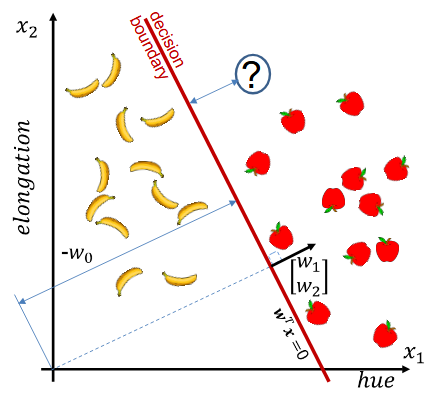

### 1.1 Função Sigmóide

Uma melhor função de classifcação e que ainda permite sua diferenciação é a Sigmoide (também chamada de regressão logística). Ele ajuda a converter dados numéricos complicados em probabilidades que são mais fáceis de interpretar:

$f(\mathbf{w}^T\mathbf{x}) = \frac{1}{1+e^{-\mathbf{w}^T\mathbf{x}}}$

Assim a classe é obtida por:

$$
classe = \begin{cases}
1 \ se \ f(\mathbf{w}^T\mathbf{x}) \geq 0.5 \ \ (\text{maçã}) \\
0 \ caso \ \ contrário \ \ (banana)
\end{cases}
$$

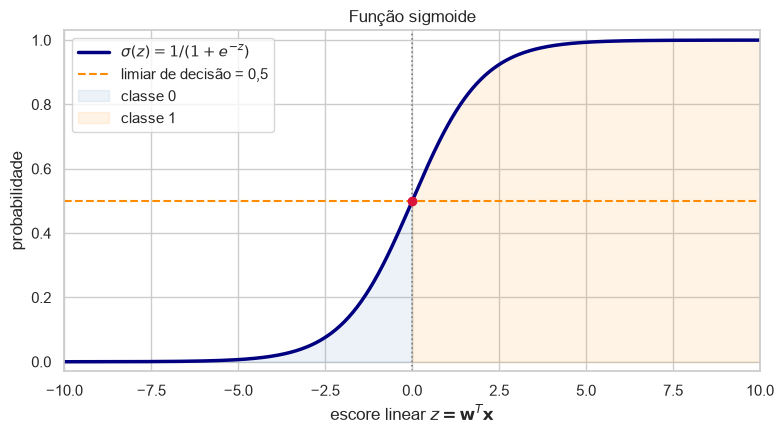

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Curva da função sigmoide
z = np.linspace(-10, 10, 500)
probabilidade = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(z, probabilidade, color='navy', linewidth=2.5,
        label=r'$\sigma(z)=1/(1+e^{-z})$')
ax.axhline(0.5, color='darkorange', linestyle='--', linewidth=1.5,
           label='limiar de decisão = 0,5')
ax.axvline(0, color='gray', linestyle=':', linewidth=1.2)
ax.fill_between(z, 0, probabilidade, where=z < 0,
                color='steelblue', alpha=0.10, label='classe 0')
ax.fill_between(z, 0, probabilidade, where=z >= 0,
                color='darkorange', alpha=0.10, label='classe 1')
ax.scatter([0], [0.5], color='crimson', zorder=3)
ax.set(xlabel=r'escore linear $z=\mathbf{w}^T\mathbf{x}$',
       ylabel='probabilidade', title='Função sigmoide')
ax.set_xlim(-10, 10)
ax.set_ylim(-0.03, 1.03)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

Mas qual é $f(\mathbf{w}^T\mathbf{x})$ ótimo?

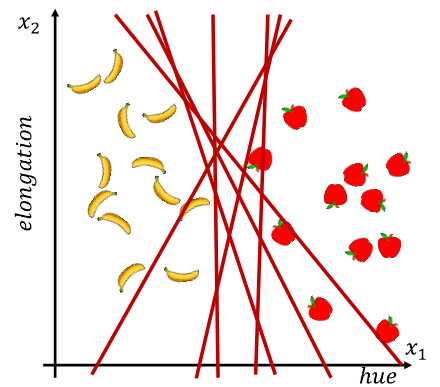

### 1.2 Função de perda

Nós precisamos de uma função $L$ que nos diga quão bom é o classificador $f(\mathbf{w}^T\mathbf{x})$, a esta função daremos o nome de **Função de Perda** (ou custo ou Loss function ou simplemente Loss), nosso objetivo é sempre minimizá-la ao encontrar seus parâmetros ajustáveis (no caso, $\mathbf{w}$).

Se tivermos alguns dados com o rótulo identificado (já classificados) podemos montar N pares de amostras $(x_i,y_i)$. Assim, em uma abordagem supervisionada, $f(\mathbf{w}^T\mathbf{x_i})$ nos entrega a classe predita $\hat{y}_i$, à qual comparamos com a classe prevista $y_i$. 


Por exemplo, a função Mean Squared Error (MSE) é uma escolha amplamente utilizada em problemas de regressão:

$$L(y, \hat{y}) = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

Onde:
- $L$ é a função de perda, a qual desejamos minimizar.
- $y$ representa os valores reais.
- $\hat{y} = f(\mathbf{w}^T\mathbf{x})$ representa os valores preditos pelo modelo.
- $N$ é o número total de amostras.

Formalmente desejamos:

$$
w_{opt} = \underset{w}{\mathrm{argmin}} \{ L(y,\hat{y})) \}
$$

### 1.3 Minimização da função de perda por gradiente descendente

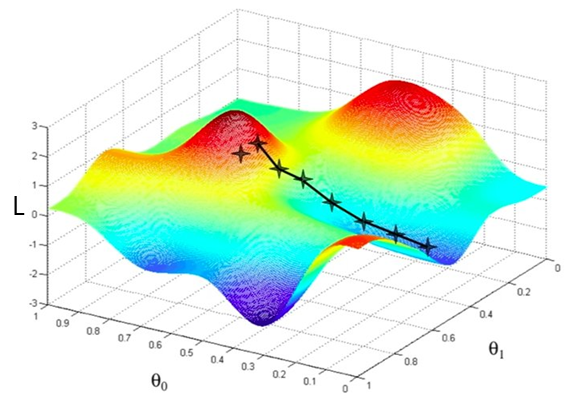

A partir de um chute aleatório inicial $\mathbf{w}_{0}$ atualiza-se os pesos iterativamente: 

$$\mathbf{w}_{k+1} ← \mathbf{w}_{k} - lr \frac{\partial L}{\partial \mathbf{w}}$$

Fazendo atualizações dos parâmetros por gradiente descendente iterativamente até o limite de iterações ou de qualidade. $lr$ é a taxa de aprendizado, representa o passo da atualização. Se pequeno, é possível ficar "preso" dentro de um mínimo local, se grande, é possível "saltar" entre mínimos globais.

## Dataset vetorial de referência



Reutilizamos o mesmo conjunto da aula de Mineração: indicadores da [plataforma IBGE Cidades](https://cidades.ibge.gov.br/brasil/sintese/rj?indicadores=96385,96386,329756,78192,143558,60030) para os **municípios do Rio de Janeiro**, combinados com a malha municipal oficial do IBGE (2022).

A célula abaixo é idêntica à da aula anterior — se o arquivo `cidades_rj.gpkg` já existe na pasta, ele é carregado direto; caso contrário, é reconstruído a partir das APIs do IBGE.

In [54]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.cm as cm
import seaborn as sns
import requests
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

np.random.seed(42)
sns.set_theme(style='whitegrid')

url_cidades = 'https://cidades.ibge.gov.br/brasil/sintese/rj?indicadores=96385,96386,329756,78192,143558,60030'
api_base = 'https://servicodados.ibge.gov.br/api/v1'
indicadores = {
    96385: 'populacao',
    96386: 'dens_demografica_ibge',
    329756: 'idhm',
    78192: 'ideb_anos_finais_publica',
    143558: 'salario_medio_mensal_sm',
    60030: 'esgotamento_sanitario_pct',
}

def valor_mais_recente(serie):
    """Retorna o valor numérico mais recente de uma série anual da API do IBGE."""
    for ano, valor in sorted(serie.items(), key=lambda item: item[0], reverse=True):
        if valor not in (None, '-', '...'):
            return pd.to_numeric(valor, errors='coerce'), int(ano)
    return np.nan, np.nan

def baixar_indicador(indicador_id, nome_coluna):
    endpoint = f'{api_base}/pesquisas/indicadores/{indicador_id}/resultados/N6[N3[33]]'
    resposta = requests.get(endpoint, timeout=30)
    resposta.raise_for_status()
    registros = []
    for item in resposta.json()[0]['res']:
        valor, ano = valor_mais_recente(item['res'])
        registros.append({
            'cod_mun6': str(item['localidade']).zfill(6),
            nome_coluna: valor,
            f'{nome_coluna}_ano': ano,
        })
    return pd.DataFrame(registros)

def baixar_populacao_historica():
    endpoint = f'{api_base}/pesquisas/indicadores/96385/resultados/N6[N3[33]]'
    resposta = requests.get(endpoint, timeout=30)
    resposta.raise_for_status()
    registros = []
    for item in resposta.json()[0]['res']:
        serie = item['res']
        registros.append({
            'cod_mun6': str(item['localidade']).zfill(6),
            'pop_2010': pd.to_numeric(serie.get('2010'), errors='coerce'),
            'pop_2022': pd.to_numeric(serie.get('2022'), errors='coerce'),
        })
    return pd.DataFrame(registros)

def limpar_colunas_ano(gdf):
    """Incorpora colunas *_ano ao nome da variável correspondente e remove o *_ano."""
    renomear = {}
    remover = []
    aliases_analise = {}

    for coluna_ano in sorted(col for col in gdf.columns if col.endswith('_ano')):
        coluna_base = coluna_ano[:-4]
        if coluna_base not in gdf.columns:
            continue

        anos = sorted(gdf[coluna_ano].dropna().astype(int).unique())
        if len(anos) == 1:
            sufixo = str(anos[0])
        elif len(anos) > 1:
            sufixo = str(anos[-1])
            print(f'Aviso: {coluna_ano} possui múltiplos anos {anos}; usando sufixo {sufixo}.')
        else:
            sufixo = 'sem_ano'

        nova_coluna = f'{coluna_base}_{sufixo}'
        renomear[coluna_base] = nova_coluna
        remover.append(coluna_ano)
        aliases_analise[nova_coluna] = coluna_base

    return gdf.rename(columns=renomear).drop(columns=remover), aliases_analise

filename = "cidades_rj.gpkg"
if not os.path.exists(filename):

    dados_ibge = None
    for indicador_id, nome_coluna in indicadores.items():
        parcial = baixar_indicador(indicador_id, nome_coluna)
        dados_ibge = parcial if dados_ibge is None else dados_ibge.merge(parcial, on='cod_mun6', how='outer')
    del dados_ibge['populacao']; del dados_ibge['populacao_ano']

    malha_path = 'BR_Municipios_2022.zip'
    if not os.path.exists(malha_path):
        malha_url = (
            'https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/'
            'malhas_municipais/municipio_2022/Brasil/BR/BR_Municipios_2022.zip'
        )

        with requests.get(malha_url, stream=True) as resposta:
            resposta.raise_for_status()
            with open(malha_path, "wb") as f:
                for bloco in resposta.iter_content(chunk_size=8192):
                    f.write(bloco)

    malha = gpd.read_file(malha_path)
    malha_rj = malha.query("SIGLA_UF == 'RJ'").copy()
    malha_rj['cod_mun6'] = malha_rj['CD_MUN'].astype(str).str[:6]
    del malha_rj['CD_MUN']; del malha_rj['SIGLA_UF']

    gdf = malha_rj.merge(dados_ibge, on='cod_mun6', how='left')
    gdf = gdf.merge(baixar_populacao_historica(), on='cod_mun6', how='left')
    gdf = gdf.rename(columns={'NM_MUN': 'municipio', 'AREA_KM2': 'area_km2'})
    gdf = gdf.to_crs('EPSG:4326')

    # Variáveis derivadas a partir dos dados oficiais.
    gdf['cresc_pop_pct'] = ((gdf['pop_2022'] / gdf['pop_2010'] - 1) * 100).round(2)
    gdf['classe_dev'] = pd.cut(
        gdf['idhm'],
        bins=[0, 0.699, 0.799, 1.0],
        labels=['Médio', 'Alto', 'Muito Alto']
    )
    gdf['classe_ideb'] = pd.cut(
        gdf['ideb_anos_finais_publica'],
            bins=[0, 3.0, 4.0, 5.0, 6.0, 10.0],
            labels=['Muito Baixo', 'Baixo', 'Médio', 'Alto', 'Muito Alto']
        )

    # Limpar anos e renomear colunas dos anos
    gdf, aliases_analise = limpar_colunas_ano(gdf)

    gdf.to_file(filename, driver="GPKG")
else:
    gdf = gpd.read_file(filename)


# print(f'Fonte IBGE Cidades: {url_cidades}')
print(f'Shape gdf limpo: {gdf.shape}')
gdf.head(3)

Shape gdf limpo: (92, 14)


,municipio,area_km2,cod_mun6,dens_demografica_ibge_2022,idhm_2010,ideb_anos_finais_publica_2023,salario_medio_mensal_sm_2024,esgotamento_sanitario_pct_2022,pop_2010,pop_2022,cresc_pop_pct,classe_dev,classe_ideb,geometry
0,Angra dos Reis,813.420,330010,205.84,0.724,4.4,3.2,69.95,169511,167434,-1.23,Alto,Médio,"MULTIPOLYGON (((-44.51649 -23.03589, -44.51633..."
1,Aperibé,94.542,330015,116.71,0.692,5.3,1.7,84.82,10213,11034,8.04,Médio,Alto,"MULTIPOLYGON (((-42.11437 -21.61204, -42.11394..."
2,Araruama,638.276,330020,203.16,0.718,4.3,1.7,32.34,112008,129671,15.77,Alto,Médio,"MULTIPOLYGON (((-42.28399 -22.93928, -42.28444..."


Relembrando as variáveis numéricas disponíveis no `gdf`. Elas serão nossos **atributos** (features, o vetor $X$) e, dependendo da tarefa, um deles será o **alvo** ($y$).

In [65]:
num_cols = gdf.describe().columns.tolist()
print('Variáveis numéricas disponíveis:')
for c in num_cols:
    print(' -', c)


Variáveis numéricas disponíveis:
 - area_km2
 - dens_demografica_ibge_2022
 - idhm_2010
 - ideb_anos_finais_publica_2023
 - salario_medio_mensal_sm_2024
 - esgotamento_sanitario_pct_2022
 - pop_2010
 - pop_2022
 - cresc_pop_pct


## 2. Regressão logística

Apesar do nome, é um **classificador**. Primeiro calcula $z=\mathbf w^T\mathbf x+b$ e depois converte o escore em probabilidade com a sigmoide:

$$P(y=1\mid\mathbf x)=\sigma(z)=\frac{1}{1+e^{-z}}.$$

Assim a classe é obtida por:

$$
classe = \begin{cases}
1 \ se \ \sigma(z) \geq 0.5 \\
0 \ caso \ \ contrário 
\end{cases}
$$

E ainda a acurácia = (Número de Previsões Corretas) / (Número Total de Previsões), em termos de Verdadeiros Positivos (TP), Verdadeiros Negativos (TN), Falsos Positivos (FP) e Falsos Negativos (FN):

$$Acc = \frac{TP + TN}{TP+TN+FP+FN}$$

Base de dados para classificação: (92, 6)


,idhm_2010,ideb_anos_finais_publica_2023,salario_medio_mensal_sm_2024,dens_demografica_ibge_2022,esgotamento_sanitario_pct_2022,bom_saneamento
0,0.724,4.4,3.2,205.84,69.95,0
1,0.692,5.3,1.7,116.71,84.82,1
2,0.718,4.3,1.7,203.16,32.34,0
3,0.684,4.1,2.4,106.82,41.54,0
4,0.728,4.0,1.7,563.65,30.79,0


Resultado do treinamento do modelo de regressão logística:

z=esgotamento_sanitario_pct_2022=
idhm_2010 × 0.2632694775246662 +
ideb_anos_finais_publica_2023 × 0.24873128736907743 +
salario_medio_mensal_sm_2024 × -0.016543992799380715 +
dens_demografica_ibge_2022 × 1.45205306976802 +
0.2382901577392606

Métricas de avaliação do modelo:
Acurácia=0.652


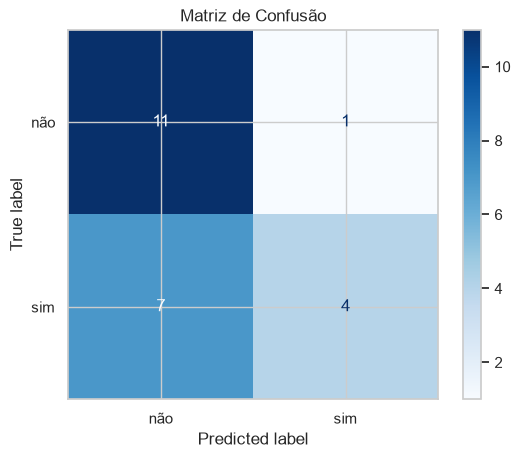

In [56]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, ConfusionMatrixDisplay

features_cls = ['idhm_2010', 'ideb_anos_finais_publica_2023',
                'salario_medio_mensal_sm_2024', 'dens_demografica_ibge_2022']
base_cls = gdf[features_cls + ['esgotamento_sanitario_pct_2022']].dropna().copy()
base_cls['bom_saneamento'] = (base_cls['esgotamento_sanitario_pct_2022'] >
                              base_cls['esgotamento_sanitario_pct_2022'].median()).astype(int)

print(f'Base de dados para classificação: {base_cls.shape}')
display(base_cls.head(5))

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    base_cls[features_cls], base_cls['bom_saneamento'], test_size=.25,
    random_state=42, stratify=base_cls['bom_saneamento'])

logistica = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
logistica.fit(X_train_cls, y_train_cls)

# Resultado do treinamento do modelo de regressão logística
print("Resultado do treinamento do modelo de regressão logística:")
print(f"\nz=esgotamento_sanitario_pct_2022=")
for i in range(len(features_cls)):
    print(f'{features_cls[i]} × {str(logistica.named_steps["logisticregression"].coef_[0][i])} +')
print(logistica.named_steps['logisticregression'].intercept_[0])

pred_log = logistica.predict(X_test_cls); prob_log = logistica.predict_proba(X_test_cls)[:, 1]

print("\nMétricas de avaliação do modelo:")
print(f'Acurácia={accuracy_score(y_test_cls, pred_log):.3f}')

ConfusionMatrixDisplay.from_predictions(y_test_cls, pred_log, display_labels=['não', 'sim'], cmap='Blues')
plt.title('Matriz de Confusão'); plt.show()

## 3. Árvore de decisão

Uma árvore cria regras do tipo “$x_j\leq t$?” e divide recursivamente os dados. Para classificação, procura a divisão que mais reduz a impureza.

![Árvore de decisão: divisões sucessivas e regiões de classificação](media/imgs/arvore_decisao.png)

Cada nó interno testa um atributo; o caminho formado pelas respostas **sim/não** termina em uma folha que atribui a classe. No gráfico à direita, esses testes aparecem como regiões de decisão alinhadas aos eixos.

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'log_loss'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

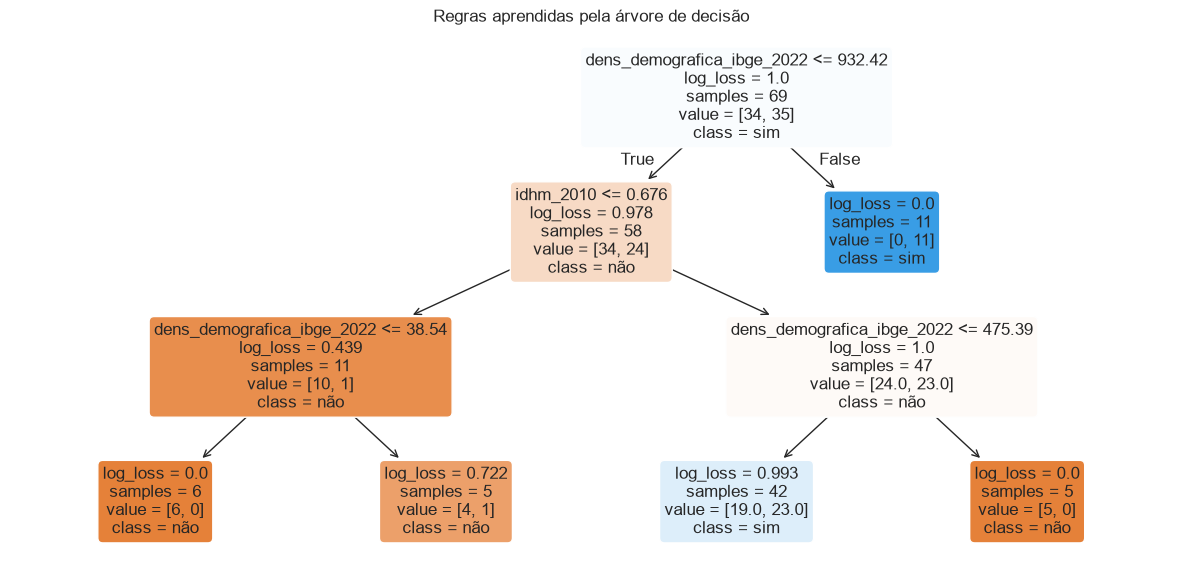

Métricas de avaliação do modelo:
Acurácia de teste: 0.826


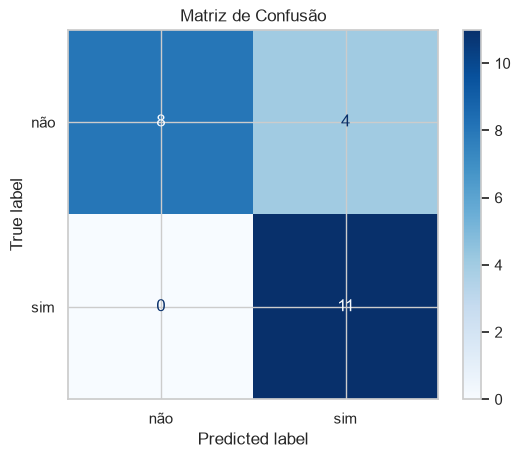

In [67]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

arvore_cls = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=42, criterion='log_loss')
arvore_cls.fit(X_train_cls, y_train_cls)
pred_arvore = arvore_cls.predict(X_test_cls)

display(arvore_cls)

fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(arvore_cls, feature_names=features_cls, class_names=['não', 'sim'],
          filled=True, rounded=True, fontsize=12, ax=ax)

ax.set_title('Regras aprendidas pela árvore de decisão'); plt.show()

print("Métricas de avaliação do modelo:")
print(f'Acurácia de teste: {accuracy_score(y_test_cls, pred_arvore):.3f}')

ConfusionMatrixDisplay.from_predictions(y_test_cls, pred_arvore, display_labels=['não', 'sim'], cmap='Blues')
plt.title('Matriz de Confusão'); plt.show()



## 4. Floresta aleatória para classificação

A floresta aleatória (Random Forest) é um método de **aprendizado em conjunto (ensemble learning)** usado para classificação e regressão.

A ideia central por trás da Random Forest é combinar as previsões de múltiplas árvores de decisão individuais para produzir uma previsão mais precisa e estável do que qualquer árvore individual poderia alcançar. Para classificação, a previsão final é determinada pela votação majoritária entre as árvores.

$$\hat y=\operatorname{moda}\{T_1(\mathbf x),\ldots,T_B(\mathbf x)\}.$$

Ao reduzir a correlação entre árvores, o conjunto costuma generalizar melhor que uma árvore isolada.

![Floresta aleatória: diversidade das árvores e votação final](media/imgs/floresta_aleatoria.png)

Cada árvore recebe uma amostra *bootstrap* e considera subconjuntos aleatórios de atributos. A diversidade reduz a correlação entre os modelos; na classificação, a previsão final é o voto majoritário.

In [76]:
from sklearn.ensemble import RandomForestClassifier

floresta_cls = RandomForestClassifier(
        n_estimators=200,       # Número de árvores.
        max_depth=None,         # Sem limite de profundidade.
        min_samples_leaf=5,     # Mínimo de amostras necessário para estar em um nó folha.
        n_jobs=-1,              # Usar todos os núcleos da CPU
        random_state=42,
        verbose=1
    )

# Treino
floresta_cls.fit(X_train_cls, y_train_cls)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.0s finished


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None


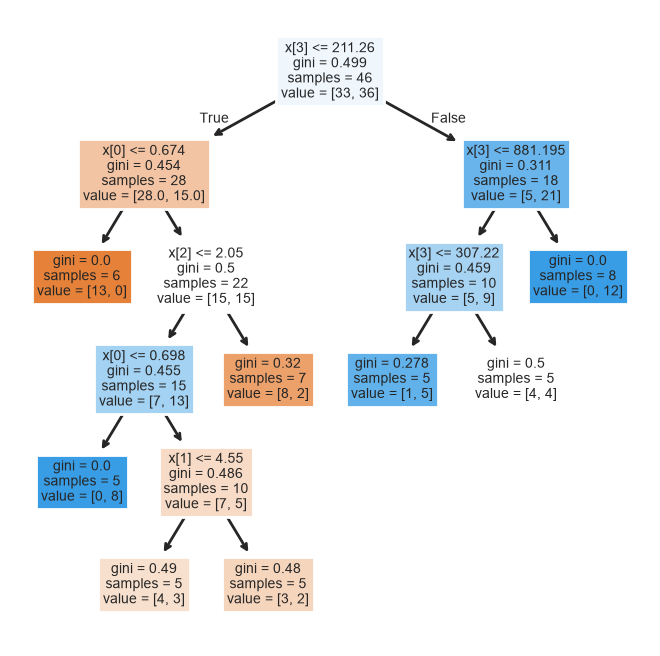

In [80]:
# Visualização

# Plot first tree of the Randomforest (index 0)
# https://stackoverflow.com/questions/40155128/plot-trees-for-a-random-forest-in-python-with-scikit-learn

from sklearn import tree

arvore_id = 0

fig, axes = plt.subplots(nrows = 1,ncols = 1, figsize = (4,4), dpi=200)
tree.plot_tree(floresta_cls.estimators_[arvore_id],
               filled = True)
fig.savefig('rf_individualtree.png')


Métricas de avaliação do modelo:
Acurácia=0.609


[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 200 out of 200 | elapsed:    0.0s finished


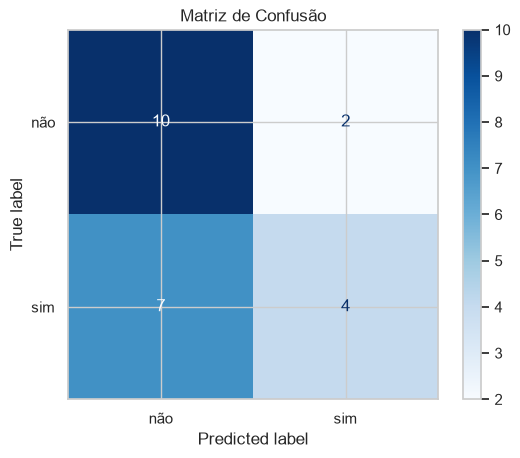

In [78]:
print("\nMétricas de avaliação do modelo:")
pred_floresta = floresta_cls.predict(X_test_cls)
print(f'Acurácia={accuracy_score(y_test_cls, pred_floresta):.3f}')

ConfusionMatrixDisplay.from_predictions(y_test_cls, pred_floresta, display_labels=['não', 'sim'], cmap='Blues')
plt.title('Matriz de Confusão'); plt.show()

## 5. Support Vector Machine (SVM)

O SVM é um classificador linear, procurando um hiperplano entre as classes. Em adição, é interessante para uma classificação não linear usando o chamado truque do kernel, mapeando implicitamente suas entradas em **espaços de características de alta dimensão** e de modo que haja um corte linear que **maximize a margem entre as classes**:

![alt text](media/imgs/svm_kernel_trick.jpeg)

Um *kernel* como o Gaussian radial basis function (RBF) permite representar fronteiras não lineares:

$$\kappa(x_i,x_j)= e^{-\gamma||x_i - x_j||^2}$$

![SVM: hiperplano, margem máxima, vetores de suporte e kernel RBF](media/imgs/svm_margem.png)

O SVM escolhe o hiperplano que maximiza a distância até as observações mais próximas, os **vetores de suporte**. 

## 6. Regressão linear

A regressão linear prevê um **valor contínuo** por uma combinação de atributos (ou pesos $\mathbf{w}$):

$$\hat y=\mathbf{w}_0+\sum_{j=1}^{p}\mathbf{w}_jx_j$$

O ajuste por mínimos quadrados escolhe os coeficientes que minimizam

$$L = \sum_{i=1}^{n}(y_i-\hat y_i)^2.$$

Relações lineares, resíduos independentes e variância aproximadamente constante favorecem este modelo.

In [59]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = ['idhm_2010', 'ideb_anos_finais_publica_2023',
                'esgotamento_sanitario_pct_2022', 'dens_demografica_ibge_2022']
Y = 'salario_medio_mensal_sm_2024'
dados_reg = gdf[X + [Y]].dropna()

print(f'Base de dados para regressão: {dados_reg.shape}')
display(dados_reg.head(5))

# Divisão dos dados em treino e teste
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    dados_reg[X], dados_reg[Y], test_size=.25, random_state=42)

# Treinamento do modelo de regressão linear
reg_linear = LinearRegression().fit(X_train_reg, y_train_reg)

# Como ficaram os coeficientes?
print(f"f(X)={Y}=")
for i in range(len(X)):
    print(f'{X[i]} × {reg_linear.coef_[i]:.4f} +')
print(reg_linear.intercept_)

# Pesos w ajustados, agora faz-se a inferência com os dados de teste nunca 
# vistos pelo modelo
pred_reg_linear = reg_linear.predict(X_test_reg)

# Métricas de avaliação do modelo
print("\nMétricas de avaliação do modelo:")
print(f'MAE={mean_absolute_error(y_test_reg, pred_reg_linear):.3f} SM')
print(f'RMSE={mean_squared_error(y_test_reg, pred_reg_linear)**0.5:.3f} SM')
print(f'R²={r2_score(y_test_reg, pred_reg_linear):.3f}')

# Outros atributos do modelo
reg_linear

Base de dados para regressão: (92, 5)


,idhm_2010,ideb_anos_finais_publica_2023,esgotamento_sanitario_pct_2022,dens_demografica_ibge_2022,salario_medio_mensal_sm_2024
0,0.724,4.4,69.95,205.84,3.2
1,0.692,5.3,84.82,116.71,1.7
2,0.718,4.3,32.34,203.16,1.7
3,0.684,4.1,41.54,106.82,2.4
4,0.728,4.0,30.79,563.65,1.7


f(X)=salario_medio_mensal_sm_2024=
idhm_2010 × 5.7480 +
ideb_anos_finais_publica_2023 × -0.1149 +
esgotamento_sanitario_pct_2022 × -0.0044 +
dens_demografica_ibge_2022 × -0.0001 +
-1.1482997449973045

Métricas de avaliação do modelo:
MAE=0.345 SM
RMSE=0.503 SM
R²=-0.075


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 5.75,-0.11,-0. ,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['idhm_2010','ideb_anos_finais_publica_2023', 'esgotamento_sanitario_pct_2022','dens_demografica_ibge_2022']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.148
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


## 7. Árvore de regressão

A estrutura é a mesma, mas as folhas retornam a **média do alvo**. Cada divisão busca a maior redução do erro quadrático:

$$\operatorname{MSE}(R)=\frac{1}{|R|}\sum_{i\in R}(y_i-\bar y_R)^2.$$

O resultado é uma função em degraus: flexível e não linear, porém incapaz de extrapolar além dos valores observados nas folhas.

![Árvore de regressão: divisões e previsões contínuas nas folhas](media/imgs/arvore_regressao.png)

Na regressão, cada folha devolve um valor contínuo — em geral, a média das amostras que chegaram ao nó. Por isso, a função aprendida tem o aspecto de uma escada.

MAE=0.290 | R²=0.310


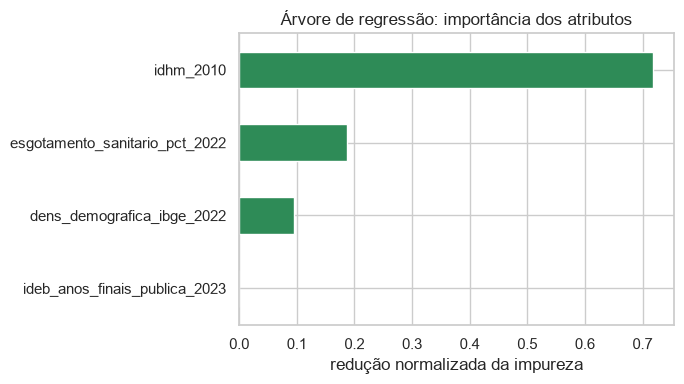

In [60]:
from sklearn.tree import DecisionTreeRegressor

arvore_reg = DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=42)
arvore_reg.fit(X_train_reg, y_train_reg)
pred_arvore_reg = arvore_reg.predict(X_test_reg)
print(f'MAE={mean_absolute_error(y_test_reg, pred_arvore_reg):.3f} | R²={r2_score(y_test_reg, pred_arvore_reg):.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
pd.Series(arvore_reg.feature_importances_, index=X).sort_values().plot.barh(ax=ax, color='seagreen')
ax.set(title='Árvore de regressão: importância dos atributos', xlabel='redução normalizada da impureza')
plt.tight_layout(); plt.show()

## 8. Floresta aleatória para regressão

Na regressão, a floresta calcula a média das previsões das árvores:

$$\hat y=\frac1B\sum_{b=1}^{B}T_b(\mathbf x).$$

A média suaviza previsões instáveis. Ainda assim, o modelo não extrapola bem e a validação geoespacial deve considerar dependência espacial: municípios vizinhos podem tornar um particionamento aleatório otimista.

In [61]:
from sklearn.ensemble import RandomForestRegressor

floresta_reg = RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                     random_state=42, n_jobs=-1)
floresta_reg.fit(X_train_reg, y_train_reg)
pred_floresta_reg = floresta_reg.predict(X_test_reg)
comparacao_reg = pd.DataFrame({
    'modelo': ['Linear', 'Árvore', 'Floresta'],
    'MAE': [mean_absolute_error(y_test_reg, pred_reg_linear),
            mean_absolute_error(y_test_reg, pred_arvore_reg),
            mean_absolute_error(y_test_reg, pred_floresta_reg)],
    'R²': [r2_score(y_test_reg, pred_reg_linear), r2_score(y_test_reg, pred_arvore_reg),
           r2_score(y_test_reg, pred_floresta_reg)]})
display(comparacao_reg.round(3))

,modelo,MAE,R²
0,Linear,0.345,-0.075
1,Árvore,0.290,0.310
2,Floresta,0.287,0.266


## 9. Redes neurais

Um neurônio artificial calcula $z=\mathbf w^T\mathbf x+b$ e aplica uma função de ativação $a=\phi(z)$. Camadas sucessivas compõem transformações:

$$\mathbf a^{(\ell)}=\phi\left(\mathbf W^{(\ell)}\mathbf a^{(\ell-1)}+\mathbf b^{(\ell)}\right).$$

A ativação introduz não linearidade. ReLU, $\max(0,z)$, é comum nas camadas ocultas. O treinamento usa retropropagação para calcular gradientes e descida do gradiente, $\theta\leftarrow\theta-\eta\nabla_\theta L$. A pequena prática mostra uma passagem direta (*forward pass*) sem biblioteca de redes.

## 10. Multilayer Perceptron (MLP) e Softmax

Um MLP é uma rede totalmente conectada com uma ou mais camadas ocultas. Para $K$ classes, a camada de saída produz *logits* $z_k$ e a **Softmax** os normaliza:

$$P(y=k\mid\mathbf x)=\frac{e^{z_k}}{\sum_{j=1}^{K}e^{z_j}}.$$

As probabilidades somam 1 e a classe prevista é a de maior probabilidade. Softmax é uma **função de saída**, não uma função de perda; normalmente é combinada com entropia cruzada. Usaremos o conjunto real `digits`, de imagens $8\times8$ de algarismos.

Acurácia multiclasse: 0.947
Soma das probabilidades das 5 primeiras imagens: [1. 1. 1. 1. 1.]


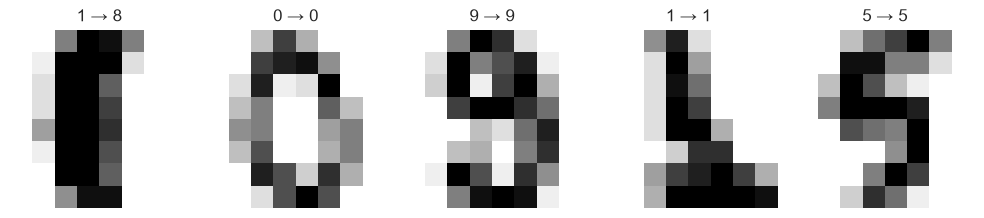

In [62]:
from sklearn.datasets import load_digits
from sklearn.neural_network import MLPClassifier

digits = load_digits()
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    digits.data, digits.target, test_size=.25, random_state=42, stratify=digits.target)
mlp = make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(64,),
                    max_iter=500, early_stopping=True, random_state=42))
mlp.fit(X_train_d, y_train_d)
probs_mlp = mlp.predict_proba(X_test_d)
pred_mlp = probs_mlp.argmax(axis=1)
print(f'Acurácia multiclasse: {accuracy_score(y_test_d, pred_mlp):.3f}')
print('Soma das probabilidades das 5 primeiras imagens:', probs_mlp[:5].sum(axis=1).round(6))

fig, axes = plt.subplots(1, 5, figsize=(10, 2.2))
for ax, imagem, real, previsto in zip(axes, X_test_d[:5], y_test_d[:5], pred_mlp[:5]):
    ax.imshow(imagem.reshape(8, 8), cmap='gray_r'); ax.set_title(f'{real} → {previsto}'); ax.axis('off')
plt.tight_layout(); plt.show()

## 11. MLP e Cross-Entropy Loss

Para um exemplo multiclasse com rótulo *one-hot* $y_k$, a entropia cruzada é

$$L=-\sum_{k=1}^{K}y_k\log(p_k)=-\log(p_{\text{classe correta}}).$$

Logo, uma previsão correta e confiante gera perda próxima de zero; atribuir baixa probabilidade à classe correta gera perda alta. A média no conjunto é a *log-loss*. Acompanhar treino e validação ajuda a detectar sobreajuste: perda de treino caindo enquanto a validação piora.

Cross-entropy no teste: 0.2524


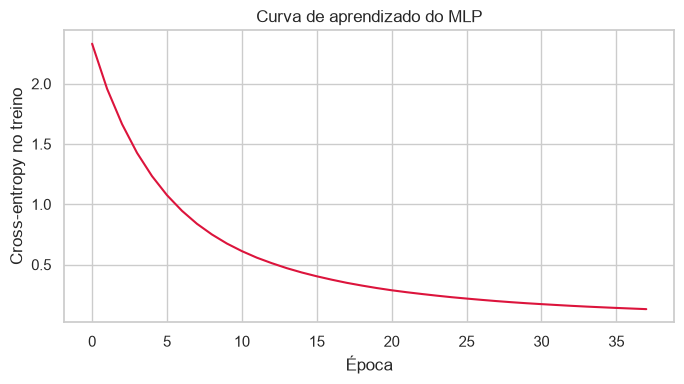

In [63]:
from sklearn.metrics import log_loss

perda_teste = log_loss(y_test_d, probs_mlp)
print(f'Cross-entropy no teste: {perda_teste:.4f}')
rede_treinada = mlp.named_steps['mlpclassifier']
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rede_treinada.loss_curve_, color='crimson')
ax.set(xlabel='Época', ylabel='Cross-entropy no treino',
       title='Curva de aprendizado do MLP')
plt.tight_layout(); plt.show()

## 12. Deep learning

**Deep learning** usa redes com várias camadas de representação. Em imagens, camadas iniciais podem responder a bordas e texturas; camadas posteriores combinam esses padrões em estradas, construções, água ou vegetação. A profundidade aumenta a capacidade, mas também exige mais dados, regularização, poder computacional e validação cuidadosa.

![Da rede rasa à rede profunda aplicada a padrões geoespaciais](media/imgs/redes_rasa_profunda.png)

Arquiteturas comuns incluem CNNs para imagens, Transformers para sequências e visão, e U-Net para segmentação. Uma MLP profunda abaixo serve como demonstração executável em CPU; ela **não substitui** uma CNN para imagens maiores. Compare sempre com um modelo simples: maior complexidade só se justifica quando melhora a generalização ou atende uma necessidade prática.

In [64]:
# Demonstração leve: duas camadas ocultas no conjunto digits
mlp_profundo = make_pipeline(StandardScaler(), MLPClassifier(
    hidden_layer_sizes=(64, 32), max_iter=500, early_stopping=True,
    validation_fraction=.15, random_state=42))
mlp_profundo.fit(X_train_d, y_train_d)
pred_profundo = mlp_profundo.predict(X_test_d)
print(f'Acurácia MLP raso:     {accuracy_score(y_test_d, pred_mlp):.3f}')
print(f'Acurácia MLP profundo: {accuracy_score(y_test_d, pred_profundo):.3f}')
print('Mais profundo não significa automaticamente melhor: compare no conjunto de teste.')

Acurácia MLP raso:     0.947
Acurácia MLP profundo: 0.960
Mais profundo não significa automaticamente melhor: compare no conjunto de teste.
